In [1]:
import sys
print("Python:", sys.executable)

Python: c:\Users\sharm\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)
print("XGBoost config:", xgb.get_config())

XGBoost version: 3.2.0
XGBoost config: {'nthread': 0, 'use_cuda_async_pool': False, 'use_rmm': False, 'verbosity': 1}


In [3]:
import xgboost as xgb
import numpy as np
import time

print("XGBoost version:", xgb.__version__)

# Small test dataset
X = np.random.rand(10000, 20)
y = np.random.randint(0, 2, 10000)

model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    device="cuda",
    eval_metric="logloss",
    random_state=42
)

start = time.time()

model.fit(X, y)

training_time = time.time() - start

print("\nGPU test completed successfully!")
print(f"Training time: {training_time:.2f} seconds")
print("Device:", model.get_xgb_params().get("device"))

XGBoost version: 3.2.0

GPU test completed successfully!
Training time: 0.37 seconds
Device: cuda


In [4]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost
from IPython.display import Markdown, display

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("xgboost version:", xgboost.__version__)

RANDOM_STATE = 42
DATA_DIR = Path(r"E:\Credit Risk Assessment System\dataset\processed_models")
PROJECT_DIR = Path(r"E:\Credit Risk Assessment System")

xgboost version: 3.2.0


In [5]:
try:
    X_train = pd.read_csv(DATA_DIR / "X_train_unscaled.csv")
    X_test = pd.read_csv(DATA_DIR / "X_test_unscaled.csv")
    y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
    y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()
except FileNotFoundError as exc:
    raise FileNotFoundError("Run 05_Data_Preprocessing_for_Modeling.ipynb first") from exc

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Feature count:", X_train.shape[1])
display(pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_%": y_test.value_counts(normalize=True).mul(100).round(2),
}))

Train: (452296, 149) Test: (61503, 149)
Feature count: 149


,train_%,test_%
TARGET,,
0,50.0,91.93
1,50.0,8.07


In [6]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda"
)
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [7]:
start = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start

print(f"Model trained in {training_time:.2f} seconds")

Model trained in 3.04 seconds


In [8]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("Sample predicted classes:", y_test_pred[:5])
print("Sample predicted probabilities (TARGET=1):", y_test_proba[:5].round(3))

Sample predicted classes: [0 0 0 0 0]
Sample predicted probabilities (TARGET=1): [0.038 0.089 0.259 0.09  0.166]


In [9]:
def evaluate(y_true, y_pred, y_proba=None) -> dict:
    """Compute standard classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    return metrics

train_metrics = evaluate(y_train, y_train_pred, model.predict_proba(X_train)[:, 1])
test_metrics = evaluate(y_test, y_test_pred, y_test_proba)

comparison = pd.DataFrame({"Train": train_metrics, "Test": pd.Series(test_metrics)}).round(4)
display(comparison)

gap = comparison.loc["Accuracy", "Train"] - comparison.loc["Accuracy", "Test"]
print(f"Observation: train/test accuracy gap is {gap:.2f} — "
      f"{'moderate, worth watching if tuning increases depth/estimators further' if gap > 0.05 else 'small, this baseline configuration is not overfitting noticeably'}.")

,Train,Test
Accuracy,0.9533,0.9195
Precision,0.9990,0.5426
Recall,0.9075,0.0141
F1 Score,0.9510,0.0275
ROC-AUC,0.9795,0.7462


Observation: train/test accuracy gap is 0.03 — small, this baseline configuration is not overfitting noticeably.


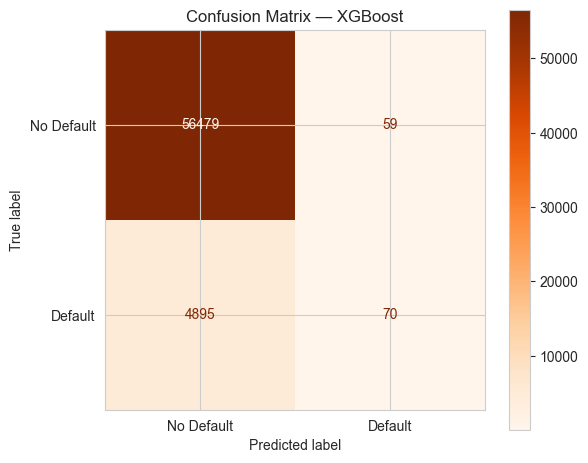

True Negatives (correctly approved): 56479
False Positives (safe applicant flagged/denied): 59
False Negatives (defaulter approved — costliest error for a bank): 4895
True Positives (correctly flagged defaulter): 70


In [10]:
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(ax=ax, cmap="Oranges")
ax.set_title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()

print(f"True Negatives (correctly approved): {tn}")
print(f"False Positives (safe applicant flagged/denied): {fp}")
print(f"False Negatives (defaulter approved — costliest error for a bank): {fn}")
print(f"True Positives (correctly flagged defaulter): {tp}")

In [11]:
report = classification_report(y_test, y_test_pred, target_names=["No Default", "Default"])
print(report)

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.54      0.01      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



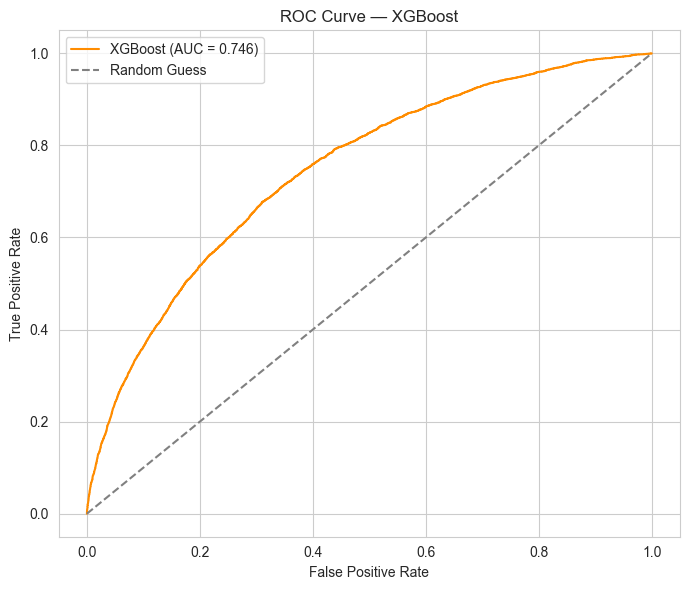

Observation: AUC of 0.746 means the model ranks a random defaulter above a random non-defaulter 74.6% of the time.


In [12]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})", color="darkorange")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC Curve — XGBoost")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observation: AUC of {auc:.3f} means the model ranks a random defaulter "
      f"above a random non-defaulter {auc*100:.1f}% of the time.")

,Feature,Importance
12,cat__NAME_INCOME_TYPE_Working,0.113652
144,num__REG_CITY_NOT_WORK_CITY,0.069491
99,cat__FLAG_OWN_CAR_Y,0.064412
30,cat__OCCUPATION_TYPE_Laborers,0.062756
19,cat__CODE_GENDER_F,0.056707
1,cat__NAME_EDUCATION_TYPE_Higher education,0.056020
4,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.051395
106,cat__NAME_TYPE_SUITE_Unaccompanied,0.042783
123,num__FLAG_DOCUMENT_3,0.041299
20,cat__CODE_GENDER_M,0.037221


,Feature,Importance
58,cat__ORGANIZATION_TYPE_Industry: type 13,0.0
103,cat__NAME_TYPE_SUITE_Other_A,0.0
84,cat__ORGANIZATION_TYPE_Telecom,0.0
102,cat__NAME_TYPE_SUITE_Group of people,0.0
92,cat__ORGANIZATION_TYPE_Transport: type 1,0.0
91,cat__ORGANIZATION_TYPE_Trade: type 7,0.0
89,cat__ORGANIZATION_TYPE_Trade: type 5,0.0
88,cat__ORGANIZATION_TYPE_Trade: type 4,0.0
86,cat__ORGANIZATION_TYPE_Trade: type 2,0.0
85,cat__ORGANIZATION_TYPE_Trade: type 1,0.0


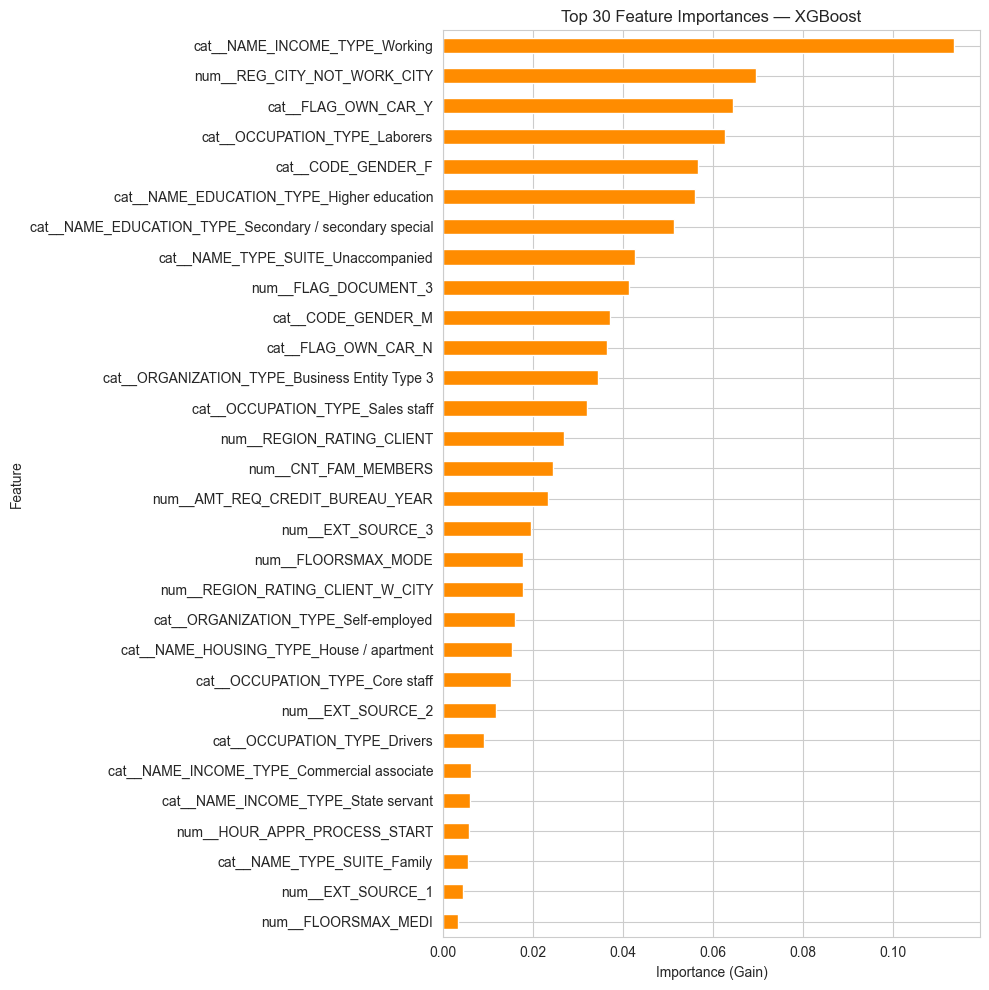

Observation: 'cat__NAME_INCOME_TYPE_Working' is the most influential feature. Engineered features in the top 30: []


In [13]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_,
}).sort_values("Importance", ascending=False)

top30 = importance_df.head(30)
bottom20 = importance_df.tail(20)
display(top30)
display(bottom20)

fig, ax = plt.subplots(figsize=(10, 10))
top30.sort_values("Importance").plot(x="Feature", y="Importance", kind="barh", ax=ax,
                                       color="darkorange", legend=False)
ax.set_title("Top 30 Feature Importances — XGBoost")
ax.set_xlabel("Importance (Gain)")
plt.tight_layout()
plt.show()

engineered_in_top30 = [f for f in top30["Feature"] if "RATIO" in f or "_PER_" in f or f == "AGE"]
print(f"Observation: '{top30.iloc[0]['Feature']}' is the most influential feature. "
      f"Engineered features in the top 30: {engineered_in_top30}")

In [14]:
model_dir = PROJECT_DIR / "models"
model_dir.mkdir(parents=True, exist_ok=True)

try:
    joblib.dump(model, model_dir / "xgboost_model.pkl")
    print("Model saved to", model_dir / "xgboost_model.pkl")
except OSError as exc:
    raise OSError(f"Could not save model to {model_dir}") from exc

Model saved to E:\Credit Risk Assessment System\models\xgboost_model.pkl


In [15]:
results_dir = PROJECT_DIR / "results"
results_dir.mkdir(parents=True, exist_ok=True)

comparison.reset_index().rename(columns={"index": "Metric"}).to_csv(
    results_dir / "xgboost_metrics.csv", index=False
)
importance_df.to_csv(results_dir / "xgboost_feature_importance.csv", index=False)

print("Saved metrics and feature importance to", results_dir)

Saved metrics and feature importance to E:\Credit Risk Assessment System\results
